In [ ]:
import csv
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Carga del dataset
from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/Dataset - Proyecto Final - Business Analytics/Features data set.csv"
ruta2 = "/content/drive/MyDrive/Dataset - Proyecto Final - Business Analytics/sales data-set.csv"
ruta3 = "/content/drive/MyDrive/Dataset - Proyecto Final - Business Analytics/stores data-set.csv"

features = pd.read_csv(ruta)
sales = pd.read_csv(ruta2)
stores = pd.read_csv(ruta3)

Mounted at /content/drive


In [ ]:
sales.columns

Index(['tienda', 'departamento', 'fecha', 'ventas_semanales', 'es_feriado'], dtype='object')

In [ ]:
#Renombrar features al español para mejorar su interpretabilidad
features = features.rename(columns={
    "Store": "tienda",
    "Date": "fecha",
    "Temperature": "temperatura",
    "Fuel_Price": "precio_combustible",
    "MarkDown1": "descuento_1",
    "MarkDown2": "descuento_2",
    "MarkDown3": "descuento_3",
    "MarkDown4": "descuento_4",
    "MarkDown5": "descuento_5",
    "CPI": "ipc",
    "Unemployment": "desempleo",
    "IsHoliday": "es_feriado"
})
sales = sales.rename(columns={
    "Store": "tienda",
    "Dept": "departamento",
    "Date": "fecha",
    "Weekly_Sales": "ventas_semanales",
    "IsHoliday": "es_feriado"
})
stores = stores.rename(columns={
    "Store": "tienda",
    "Type": "tipo_tienda",
    "Size": "tamanio_tienda"
})

In [ ]:
#Conversión de fechas
features["fecha"] = pd.to_datetime(features["fecha"], format="%d/%m/%Y")
sales["fecha"] = pd.to_datetime(sales["fecha"], format="%d/%m/%Y")

In [ ]:
sales.head(10)

,tienda,departamento,fecha,ventas_semanales,es_feriado
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False


In [ ]:
#Ahora lo que hacemos es un merge ya que tenemos las variables por separado tanto en X como en Y
#Primero uno sales y features por tienda y fecha para tenerlas en una misma tabla sin romper y mezclar los datos
data = pd.merge(
    sales,
    features,
    on=["tienda", "fecha"],
    how="inner"
)
#Luego lo unimos a la tercer tabla que es stores, ahora ya tenemos todo listo para realizar una regresión lineal
data = pd.merge(
    data,
    stores,
    on="tienda",
    how="inner"
)

In [ ]:
#Creamos variables temporales
data['anio'] = data['fecha'].dt.year
data['mes'] = data['fecha'].dt.month
data['semana'] = data['fecha'].dt.isocalendar().week

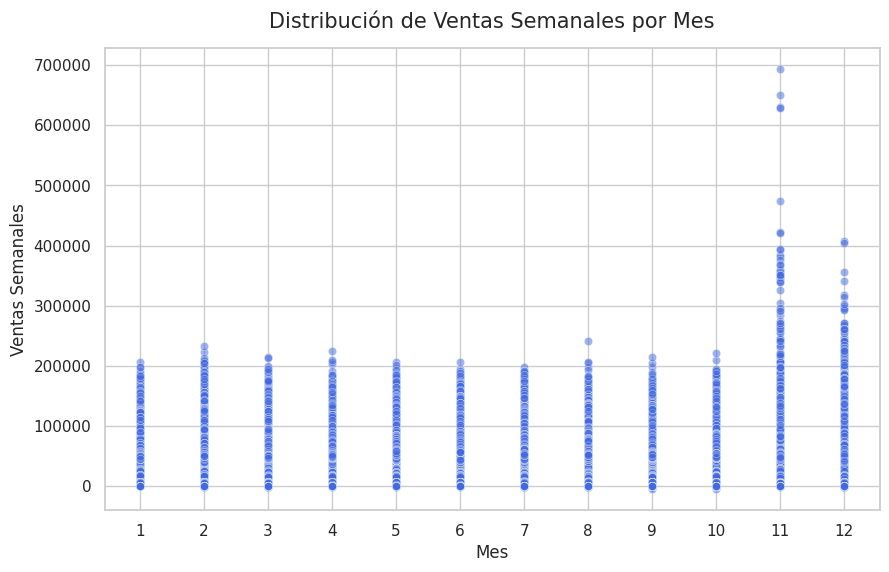

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# Configuración de estilo para que se vea mejor en diapositivas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear el gráfico con seaborn para mejor estética
scatter = sns.scatterplot(data=data, x='mes', y='ventas_semanales', alpha=0.5, color='royalblue')

plt.title("Distribución de Ventas Semanales por Mes", fontsize=15, pad=15)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ventas Semanales", fontsize=12)
plt.xticks(range(1, 13))

# Guardar la imagen en alta calidad
nombre_archivo = "analisis_exploratorio_ventas.png"
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
plt.show()

# Descargar automáticamente
files.download(nombre_archivo)

Se puede esperar que hay eventos de pico en meses de Noviembre y Diciembre

In [ ]:
#Generamos y construimos una matriz de correlación para entender como se interpretan las variables entre sí
cols_modelo = [
    'ventas_semanales',
    'temperatura',
    'precio_combustible',
    'ipc',
    'desempleo',
    'mes',
    'anio'
]

data_corr = data[cols_modelo]

In [ ]:
corr = data_corr.corr()

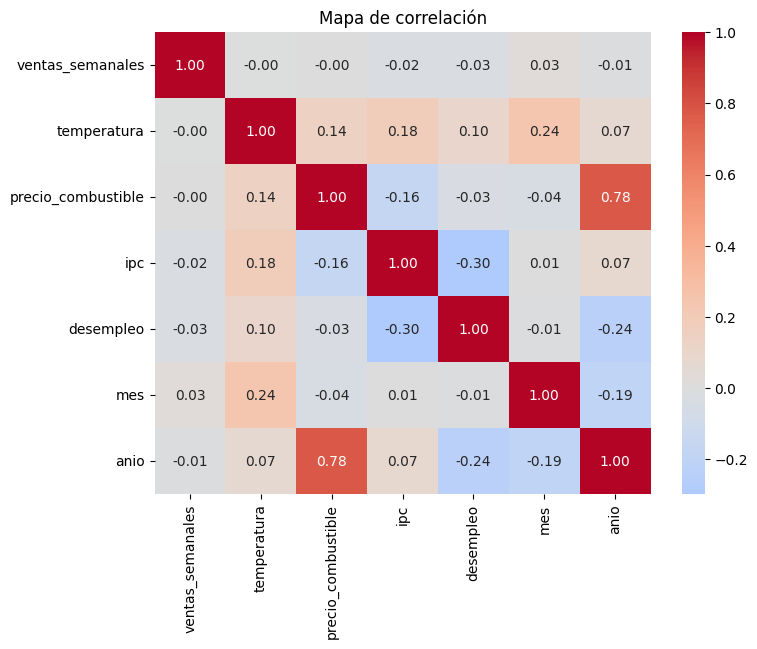

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(8,6))
fig_corr = sns.heatmap(corr,
            annot=True,      # muestra valores numéricos
            fmt=".2f",       # 2 decimales
            cmap="coolwarm",
            center=0)

plt.title("Mapa de correlación")

# Guardar la imagen
plt.savefig("mapa_correlacion.png", dpi=300, bbox_inches='tight')
plt.show()

# Descargar el archivo
files.download("mapa_correlacion.png")

Como se puede observar en la matriz de correlación, existe una correlación positiva entre el precio del combustible y el año, lo que sugiere una tendencia creciente del precio a lo largo del tiempo. Por otro lado, se observa una correlación negativa entre el desempleo y el índice de precios al consumidor (IPC), indicando que cuando una variable aumenta, la otra tiende a disminuir. Cabe aclarar que esta relación refleja asociación estadística y no necesariamente causalidad.

In [ ]:
#Si hacemos una pequeña pero estadisticamente buena en observación, los NaN (ubicados en los descuentos) representan mas del 50% del dataset por ende eso causaria errores a la hora de entrenar el modelo de regresión.
X.isna().sum()

In [ ]:
#Cambiamos los NaN de los descuentos (significan que simplemente no hubo, no es por error de carga ni nada) y los reemplazamos por 0 para que sklearn no falle
cols_desc = ['descuento_1','descuento_2','descuento_3','descuento_4','descuento_5']

data[cols_desc] = data[cols_desc].fillna(0)

In [ ]:
data[cols_desc].isna().sum()

,0
descuento_1,0
descuento_2,0
descuento_3,0
descuento_4,0
descuento_5,0


In [ ]:
#Intento 1 para la construcción de la regresión
#Selección de variables, se saco el descuento 4 por posible multicolinealidad con el descuento 1
X = data[[
    'ipc',
    'desempleo',
    'precio_combustible',
    'es_feriado',
    'descuento_1',
    'descuento_2',
    'descuento_3',
    'descuento_5',
    'tamanio_tienda'
]]

y = data['ventas_semanales']

In [ ]:
#Ahora que entendemos como se relacionan, comenzemos a probar distintos modelos para la regresión
#Para ello, utilizaremos la libreria sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

modelo = LinearRegression()
modelo.fit(X, y)

pred = modelo.predict(X)

print("R²:", round(r2_score(y, pred), 4))
print("Intercepto:", round(modelo.intercept_, 2))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})

print(coeficientes.sort_values(by='Coeficiente', ascending=False))

R²: 0.0613
Intercepto: 9529.1
             Variable  Coeficiente
3          es_feriado   471.773511
6         descuento_3     0.120333
8      tamanio_tienda     0.089031
7         descuento_5     0.074318
4         descuento_1     0.011892
5         descuento_2    -0.008084
0                 ipc   -15.881075
1           desempleo  -194.965278
2  precio_combustible  -499.761346


In [ ]:
#Probamos con ventas sesgadas (ventas de la semana anterior) ya que en Retail se considera que tienen un gran peso y podria mejorar significativamente el R cuadrado.
data = data.sort_values(['tienda','departamento','fecha'])

data['ventas_lag_1'] = (
    data.groupby(['tienda','departamento'])['ventas_semanales']
    .shift(1)
)

data = data.dropna()

In [ ]:
#Incluimos en la nueva regresión para mejorar el modelo
X = data[['ventas_lag_1',
          'ipc','desempleo','precio_combustible',
          'es_feriado','descuento_1','descuento_2',
          'descuento_3','descuento_5','tamanio_tienda',
          'mes','semana']]

y = data['ventas_semanales']

In [ ]:
# data = data.drop(columns=['es_feriado_x'])
# data = data.rename(columns={'es_feriado_y': 'es_feriado'})

In [ ]:
corr_X = X.corr()
print(corr_X)

                         ipc  desempleo  precio_combustible  es_feriado  \
ipc                 1.000000  -0.299953           -0.164210   -0.001944   
desempleo          -0.299953   1.000000           -0.033853    0.010460   
precio_combustible -0.164210  -0.033853            1.000000   -0.078281   
es_feriado         -0.001944   0.010460           -0.078281    1.000000   
descuento_1        -0.055558   0.050285            0.061371   -0.035586   
descuento_2        -0.039534   0.020940           -0.220895    0.334818   
descuento_3        -0.023590   0.012818           -0.102092    0.427960   
descuento_4        -0.049628   0.024963           -0.044986   -0.000562   
descuento_5         0.060630  -0.003843           -0.128065   -0.053719   
tamanio_tienda     -0.003314  -0.068238            0.003361    0.000593   

                    descuento_1  descuento_2  descuento_3  descuento_4  \
ipc                   -0.055558    -0.039534    -0.023590    -0.049628   
desempleo              0.0

In [ ]:
#Ejecutamos
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

modelo = LinearRegression()
modelo.fit(X, y)

pred = modelo.predict(X)

print("R2:", round(r2_score(y, pred),4))

R2: 0.9021


In [ ]:
#Realizamos una primera predicción ya que el modelo presenta mejorias en sus resultados
nueva_semana = X.iloc[-1:].copy()
pred_futura = modelo.predict(nueva_semana)

print("Predicción próxima semana:", pred_futura)

Predicción próxima semana: [1193.79114867]


Dado el comportamiento reciente y las condiciones actuales, el modelo proyecta ventas aproximadas de 1195.93 para la próxima semana.

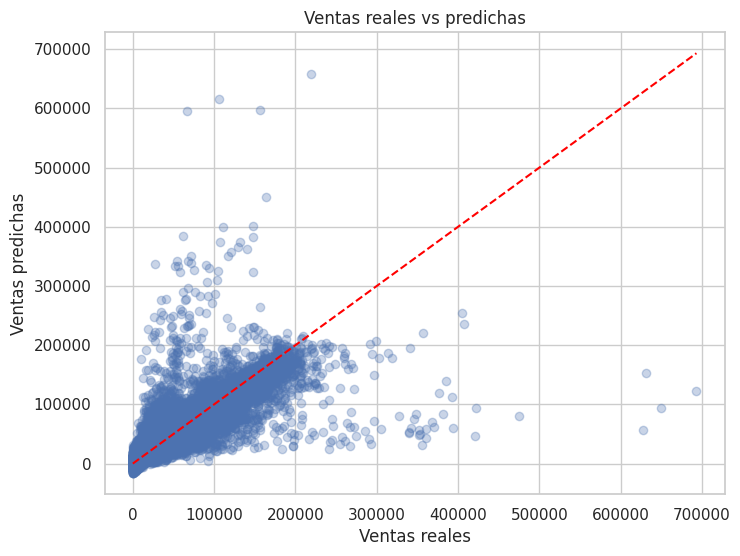

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(8,6))
plt.scatter(y, pred, alpha=0.3)
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Ventas reales vs predichas")

# Línea ideal 45°
plt.plot([y.min(), y.max()],
         [y.min(), y.max()], color='red', linestyle='--')

# Guardar la imagen
nombre_grafico = "ventas_reales_vs_predichas.png"
plt.savefig(nombre_grafico, dpi=300, bbox_inches='tight')
plt.show()

# Descargar el archivo
files.download(nombre_grafico)

Se observa que el modelo tiende a subestimar las ventas más altas, lo que sugiere que la regresión lineal capta adecuadamente la tendencia general pero presenta limitaciones para modelar valores extremos.

Procedemos a plicar transformación logaritmica para reducir el impacto de outliers y mejorar la distribución de la nube

In [ ]:
import numpy as np

# 1 eliminar negativos
data = data[data['ventas_semanales'] >= 0]

# 2 crear lag
data['ventas_lag_1'] = (
    data.groupby(['tienda','departamento'])['ventas_semanales']
    .shift(1)
)

# 3 eliminar NaN del lag
data = data.dropna()

# 4 separar
X = data[['ventas_lag_1',
          'ipc','desempleo','precio_combustible',
          'es_feriado','descuento_1','descuento_2',
          'descuento_3','descuento_5','tamanio_tienda',
          'mes','semana']]
y = data['ventas_semanales']

# 5 log seguro
y_log = np.log1p(y)

# 6 entrenamos
modelo.fit(X, y_log)

pred_log = modelo.predict(X)
pred = np.expm1(pred_log)

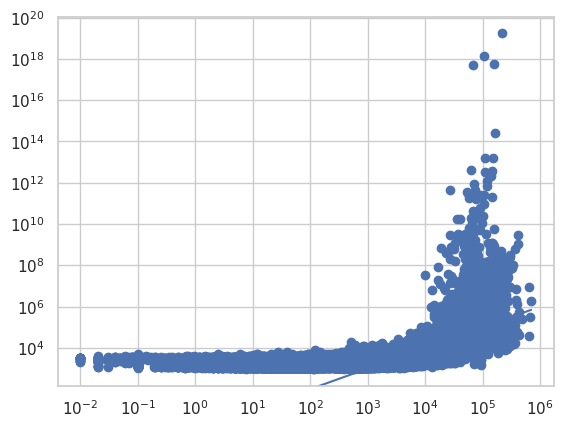

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(y, pred)
plt.xscale("log")
plt.yscale("log")
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()

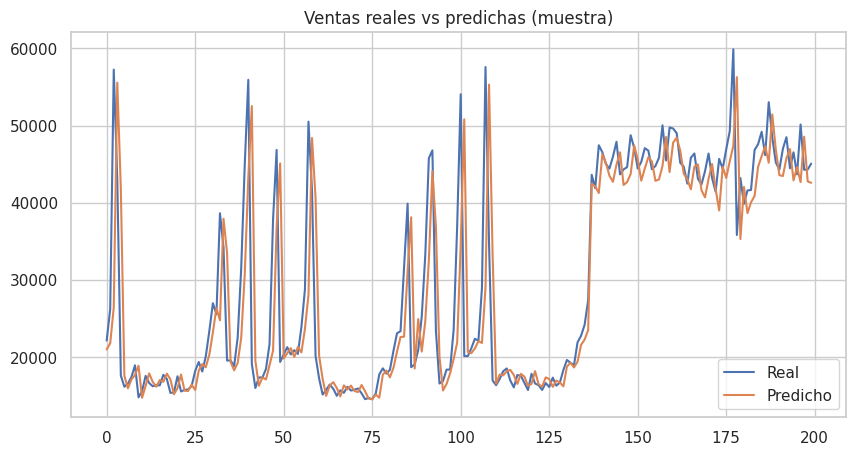

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(10,5))

plt.plot(y.values[:200], label="Real")
plt.plot(pred[:200], label="Predicho")

plt.legend()
plt.title("Ventas reales vs predichas (muestra)")

# Guardar la imagen
nombre_muestra = "ventas_muestra_comparativa.png"
plt.savefig(nombre_muestra, dpi=300, bbox_inches='tight')
plt.show()

# Descargar el archivo
files.download(nombre_muestra)

In [ ]:
# Una vez terminado con todas los flujos de trabajo para el preprocesamiento y la regresión lineal
# Exportamos el dataframe 'data' que es el que contiene los cambios y las nuevas variables
data.to_csv("dataset_limpio.csv", index=False)

# En Colab:
# 1. Se guarda en la carpeta de archivos (icono de carpeta a la izquierda)
# 2. Podes descargarlo haciendo click derecho -> Descargar
# 3. Luego lo abrís con Power BI (Obtener datos → Texto/CSV)

NameError: name 'df_final' is not defined